In [ ]:
!pip install opencv-python matplotlib

In [3]:
import os
from pathlib import Path

import torch
from numpy.typing import NDArray
from PIL import Image
import matplotlib.pyplot as plt

from src.utils.read_write import read_yaml
from visualisation.att_visualisation_utils import get_model, prepare_img, normalize_img, get_attentions, matplotlib_colors, overlay_attention

CWD = Path(os.getcwd()).parent
CONFIG_PATH = CWD / "configs" / "supervised_dino.yaml"
DATA_DIR = CWD / "data"
OUTPUR_DIR = CWD / "data" / "attention"

PATCH_SIZE = 16
FINE_TUNED = False

In [2]:
MODEL_DIR = "2026-03-06_12-10-34_corn1500_dino_sl_clean"
FILE_NAME = "epoch=54-val/val_weighted_accuracy=0.85.ckpt"
MODEL_CHECKPOINT = Path(CWD) / "data" / "model_checkpoints" / MODEL_DIR / FILE_NAME

cfg = read_yaml(CONFIG_PATH)
model = get_model(cfg=cfg, fine_tuned=FINE_TUNED, patch_size=PATCH_SIZE, model_checkpoint=MODEL_CHECKPOINT)
device = torch.accelerator.current_accelerator()
for p in model.parameters():
    p.requires_grad = False
model.eval()
model.to(device)

=> loaded backbone from checkpoint 'dino/dino_vitbase16_pretrain/dino_vitbase16_pretrain_full_checkpoint.pth' with msg _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight'])


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [4]:
def plot_attention(
        file_name: Path,
        num_plots: int,
        img: NDArray,
        attentions: NDArray,
        color: tuple[float, float, float]=(1.0, 0.0, 0.0),
        alpha: float=0.6,
        create_overlay: bool=False,
        color_map: str="viridis"
):
    for i in range(num_heads):
        fig = plt.figure(figsize=(5, 5), frameon=False)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        ax = plt.gca()

        if i < num_plots:
            if create_overlay:
                plt_img = overlay_attention(img, attentions[i], color=color, alpha=alpha)
                ax.imshow(plt_img)
            else:
                plt_img = normalize_img(attentions[i], uint=False)
                ax.imshow(plt_img, cmap=color_map)
            file_name_head = OUTPUR_DIR / (file_name.name + f"_head{str(i + 1)}.png")
            fig.savefig(file_name_head)
            print(f"{file_name_head.relative_to(DATA_DIR)} saved.")
            ax.set_title(f"Head {i+1}", color='white')
        ax.axis('off')

    plt.show()

attention/testing_grade4_img25mask_th0.6_frozen_head1.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head2.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head3.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head4.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head5.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head6.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head7.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head8.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head9.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head10.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head11.png saved.
attention/testing_grade4_img25mask_th0.6_frozen_head12.png saved.


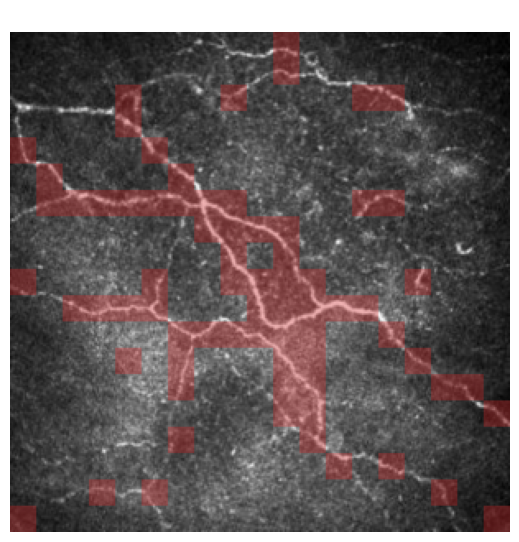

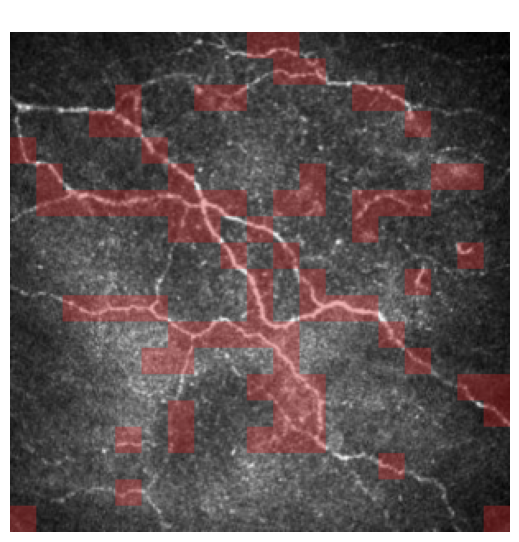

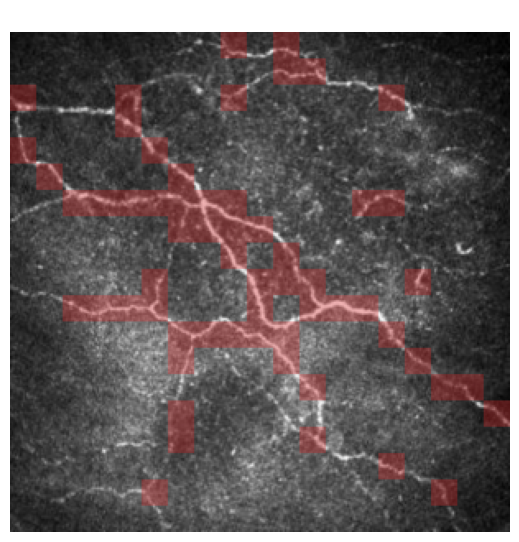

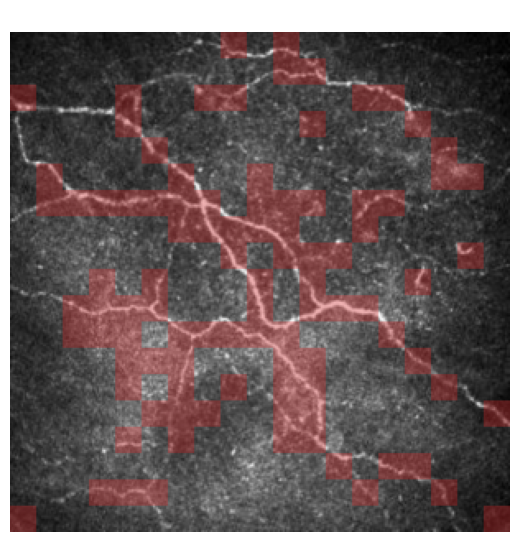

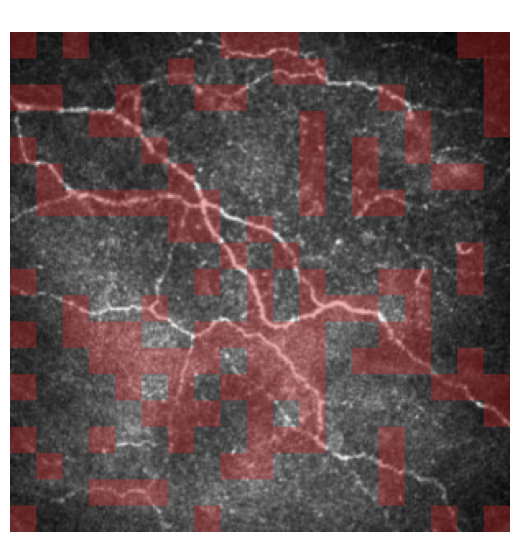

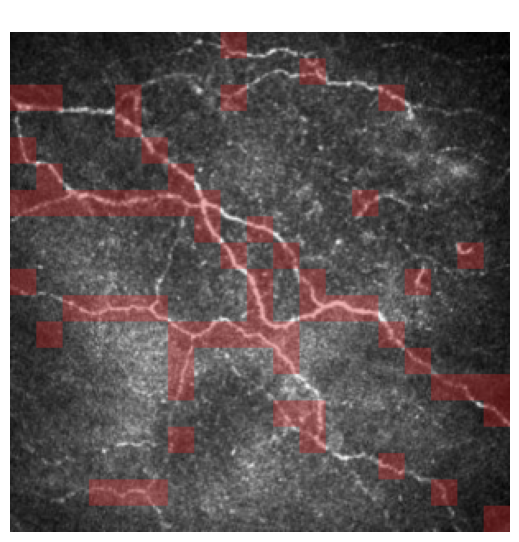

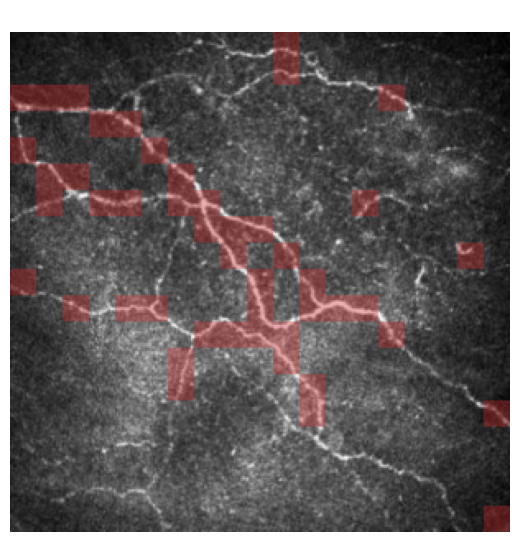

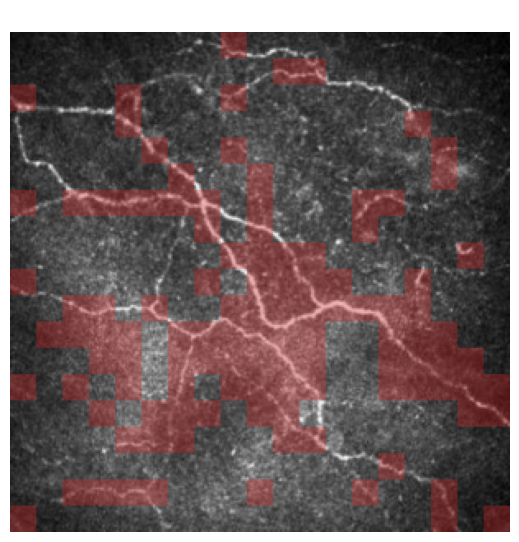

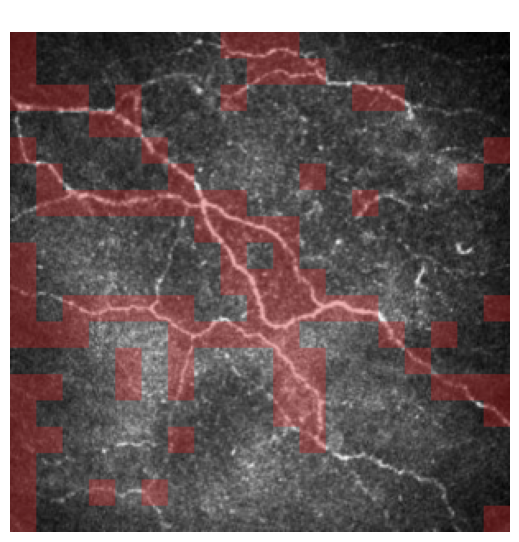

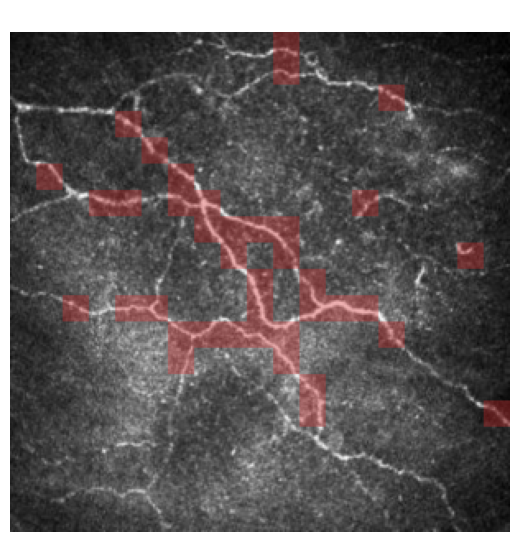

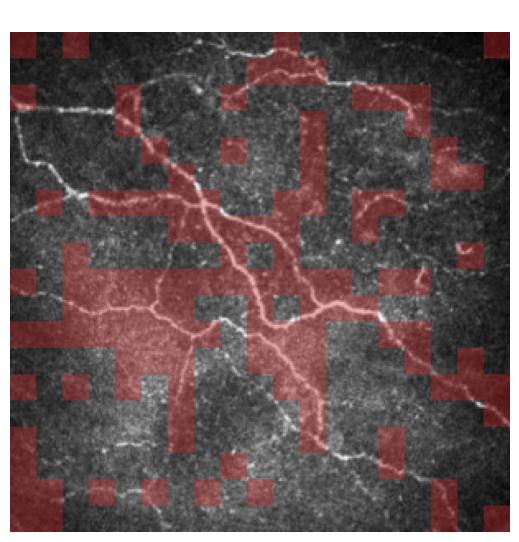

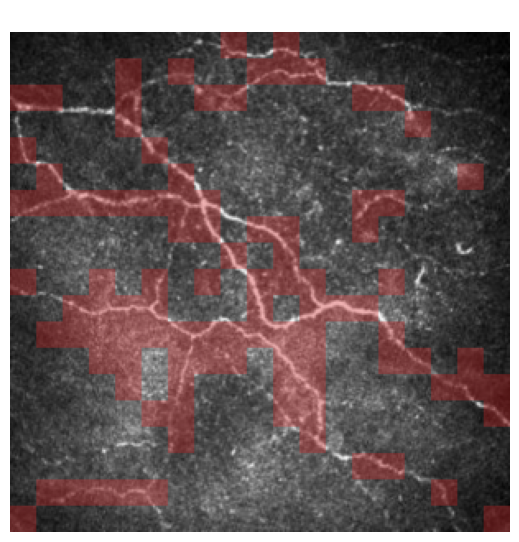

In [7]:
threshold = 0.6 #  % of mass to keep
# open image
DATA_SET = "CORN-3_orig"
level = "grade4"
img_name = "25.tif"
file_dir = DATA_DIR / DATA_SET / level / img_name
ft_or_frozen = "ft" if FINE_TUNED else "frozen"

img = Image.open(file_dir)

img = prepare_img(img, patch_size=PATCH_SIZE).to(device)

num_heads, attentions, th_attn = get_attentions(model, img, threshold)

# save attentions heatmaps
os.makedirs(OUTPUR_DIR, exist_ok=True)

img_uint8 = normalize_img(img)
image = img_uint8.squeeze().permute((1, 2, 0)).detach().cpu().numpy()

plt_cmap = "tab10"
colors = matplotlib_colors(10, plt_cmap)
file_name = OUTPUR_DIR / f"testing_{level}_img{img_name.split(".")[0]}mask_th{str(threshold)}_{ft_or_frozen}"
plot_attention(file_name, num_heads, image, th_attn, color=colors[3], alpha=0.35, create_overlay=True)
